# $\mathrm{Ca}_{\mathrm{V}}1.2$ | WT | experimental RMSD

This notebook compares complete RMSD distributions for vanilla and targeted-MSA-masked ensembles after the established 3 Å convergence filter. For Kv2.1, the convergence manifest is joined explicitly by PDB basename and rows flagged by the corrected v2 chain-mapping analysis are excluded. Each experimental reference is kept separate. Recycle snapshots are correlated, so effect sizes are descriptive and nominal significance tests are intentionally not emphasized.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'shared').is_dir())
sys.path.insert(0, str(repo_root))
import importlib
import shared.rmsd_analysis as rmsd_utils
importlib.reload(rmsd_utils)
from shared.plotting import (NAV15_EXPERIMENTAL_STYLES,RMSD_REFERENCE_STYLES,ensemble_protocol_palette,NAV15_PALETTE)
from shared.rmsd_analysis import (principal_measurements, protocol_effects, protocol_label, reference_preference, rmsd_columns, summary_statistics, summarize_reference_preference, humanize_measurement, apply_kv21_rmsd_qc)
CHANNEL='cav12'; CONDITION='wt'
SOURCE=repo_root/'cav12/dataRMSD/Cav12_all_models_all_references_RMSD_contacts_OK3.csv'
OUT=repo_root/'cav12'/'dataRMSD'/'analysis'/'wt'
FIG=OUT/'figures'; OUT.mkdir(parents=True,exist_ok=True); FIG.mkdir(parents=True,exist_ok=True)
header=pd.read_csv(SOURCE,nrows=0)
measurements=principal_measurements(header,CHANNEL,12)
companions=[]
for c in measurements:
    stem=c.removesuffix('rmsd_A'); companions += [stem+'matched_atoms',stem+'atom_coverage']
chain_measurements=[c for c in rmsd_columns(header) if 's6_bundle_working__chain_' in c and '__ca__core_aligned' in c]
metadata=['dataset','sequence_condition','protocol','pdb_file','reference_id','analysis_status','analysis_error']
diagnostics=['d4_mapping_rmsd_gap_A','all24_improvement_over_d4_A','selected_core_postfit_rmsd_A']
usecols=[c for c in dict.fromkeys(metadata+measurements+companions+chain_measurements+diagnostics) if c in header]
df=pd.read_csv(SOURCE,usecols=usecols,low_memory=False)
df=df[df.sequence_condition.astype(str).str.lower().eq(CONDITION)].copy()
if CHANNEL=='kv21':
    manifest_path=repo_root/'kv21/dataRMSF/qc/kv21_all_ok3_selection_manifest.csv'
    manifest=pd.read_csv(manifest_path,usecols=['pdb_basename','all_ok_3'])
    selected=set(manifest.loc[manifest.all_ok_3.fillna(False),'pdb_basename'].astype(str))
    before=len(df); df=df[df.pdb_file.astype(str).map(lambda x: Path(x).name).isin(selected)].copy()
    after_convergence=len(df)
    if 'analysis_status' in df: df=df[df.analysis_status.eq('ok')].copy()
    after_mapping=len(df)
    df=apply_kv21_rmsd_qc(df,repo_root)
    print(f'Kv2.1 selection: {before:,} rows → {after_convergence:,} allOk3 rows → {after_mapping:,} v2 mapping-QC rows → {len(df):,} final structural-QC rows')
if CHANNEL=='nav15': df['protocol']=df['dataset'].str.replace(CONDITION+'_','',regex=False)
df['Protocol']=df.protocol.map(protocol_label)
print(f'{len(df):,} rows; {df.pdb_file.nunique():,} unique models; {len(measurements)} principal measurements')
measurements

29,988 rows; 9,996 unique models; 12 principal measurements


['pore_domain__ca__core_aligned_rmsd_A',
 'pore_domain__ca__local_aligned_rmsd_A',
 'IS6__ca__core_aligned_rmsd_A',
 'IIS6__ca__core_aligned_rmsd_A',
 'g402_region__ca__core_aligned_rmsd_A',
 'g402_region__ca__local_aligned_rmsd_A',
 'g406_region__ca__core_aligned_rmsd_A',
 'g406_region__ca__local_aligned_rmsd_A',
 'IVS6__ca__core_aligned_rmsd_A',
 'IS6_IVS6_interface__ca__core_aligned_rmsd_A',
 'small_residue_nexus__ca__core_aligned_rmsd_A',
 'small_residue_nexus__ca__local_aligned_rmsd_A']

In [2]:
# EDIT THIS CELL to change publication-facing titles, labels, order, or colors.
PLOT_SETTINGS = {
    'channel_label': '$\\mathrm{Ca}_{\\mathrm{V}}1.2$',
    'condition_label': 'WT',
    'reference_order': [x for x in {
        'kv21':['8SD3 | WT','8SDA | L403A'],
        'nav15':['8VYJ | native open I','8VYK | native open II','7DTC | intermediate-inactivated','6UZ3 | historical','7FBS | engineered QQQ open','8T6L | toxin-bound'],
        'cav12':['8HLP','8WE6','8FD7'],
    }[CHANNEL]],
    'protocol_order': ['Vanilla','Masked','Masked v2','Masked v2 no IFM'],
    'colors': ensemble_protocol_palette(CHANNEL,CONDITION),
    'main_title': '$\\mathrm{Ca}_{\\mathrm{V}}1.2$'+f" | {CONDITION.upper()} | experimental-reference RMSD",
    'rmsd_axis': 'Cα RMSD (Å)',
}
if CHANNEL=='nav15':
    PLOT_SETTINGS['colors'].update({'Masked v2':NAV15_PALETTE['WT_MASKED_V2'] if CONDITION=='wt' else NAV15_PALETTE['QQQ_MASKED_V2'],'Masked v2 no IFM':NAV15_PALETTE['WT_MASKED_V2_NOIFM']})
REFERENCE_LABELS={
    '8SD3':'8SD3 | WT','8SDA':'8SDA | L403A',
    '8VYJ':'8VYJ | native open I','8VYK':'8VYK | native open II',
    '7DTC':'7DTC | intermediate-inactivated','6UZ3':'6UZ3 | historical',
    '7FBS':'7FBS | engineered QQQ open','8T6L':'8T6L | toxin-bound',
    '8HLP':'8HLP','8WE6':'8WE6','8FD7':'8FD7',
}
df['Reference']=df.reference_id.map(REFERENCE_LABELS).fillna(df.reference_id)
all_protocols=[x for x in PLOT_SETTINGS['protocol_order'] if x in set(df.Protocol)]
main_protocols=([x for x in ['Vanilla','Masked'] if x in set(df.Protocol)] if CHANNEL=='nav15' else all_protocols)
main_df=df[df.Protocol.isin(main_protocols)].copy()
active_protocols=main_protocols
PLOT_SETTINGS

{'channel_label': '$\\mathrm{Ca}_{\\mathrm{V}}1.2$',
 'condition_label': 'WT',
 'reference_order': ['8HLP', '8WE6', '8FD7'],
 'protocol_order': ['Vanilla', 'Masked', 'Masked v2', 'Masked v2 no IFM'],
 'colors': {'Vanilla': '#DCEBF8', 'Masked': '#3978B5'},
 'main_title': '$\\mathrm{Ca}_{\\mathrm{V}}1.2$ | WT | experimental-reference RMSD',
 'rmsd_axis': 'Cα RMSD (Å)'}

## Counts and measurement completeness

,Protocol,reference_id,rows,unique_models
0,Masked,8FD7,4996,4996
1,Masked,8HLP,4996,4996
2,Masked,8WE6,4996,4996
3,Vanilla,8FD7,5000,5000
4,Vanilla,8HLP,5000,5000
5,Vanilla,8WE6,5000,5000


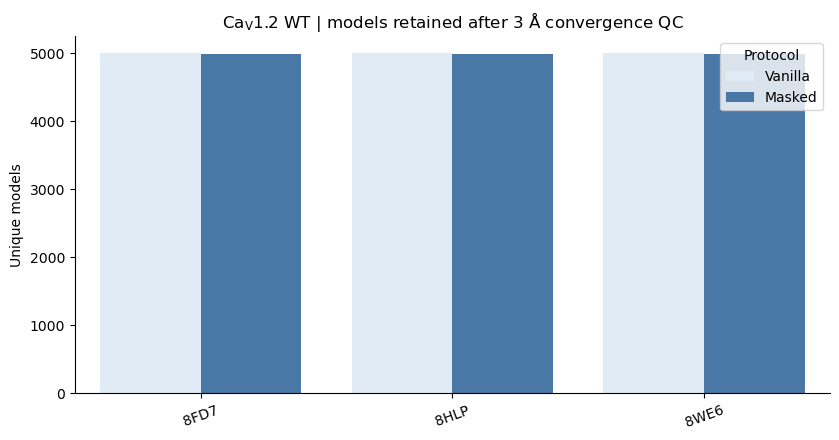

In [3]:
counts=main_df.groupby(['Protocol','reference_id']).agg(rows=('pdb_file','size'),unique_models=('pdb_file','nunique')).reset_index()
counts.to_csv(OUT/'model_counts.csv',index=False)
display(counts)
counts['Reference']=counts.reference_id.map(REFERENCE_LABELS).fillna(counts.reference_id)
fig,ax=plt.subplots(figsize=(8.5,4.5)); sns.barplot(data=counts,x='Reference',y='unique_models',hue='Protocol',hue_order=active_protocols,palette=PLOT_SETTINGS['colors'],ax=ax); ax.set(xlabel='',ylabel='Unique models',title=f"{PLOT_SETTINGS['channel_label']} {PLOT_SETTINGS['condition_label']} | models retained after 3 Å convergence QC"); ax.tick_params(axis='x',rotation=20); sns.despine();fig.tight_layout(); fig.savefig(FIG/'01_model_counts.png',dpi=300); plt.show()

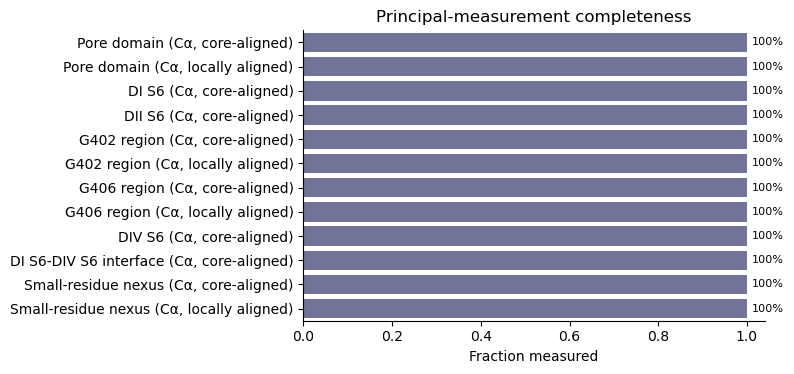

In [4]:
missing=pd.DataFrame({'measurement':measurements,'missing_fraction':[pd.to_numeric(df[c],errors='coerce').isna().mean() for c in measurements]})
missing['available_fraction']=1-missing['missing_fraction']
missing['label']=missing.measurement.map(humanize_measurement)
missing.to_csv(OUT/'coverage_missing_summary.csv',index=False)
fig,ax=plt.subplots(figsize=(8,max(3,.32*len(missing)))); sns.barplot(data=missing,y='label',x='available_fraction',color='#6B6E9E',ax=ax); ax.set(xlim=(0,1.04),xlabel='Fraction measured',ylabel='',title='Principal-measurement completeness');
for patch,value in zip(ax.patches,missing.available_fraction):
    ax.text(min(value+.012,1.015),patch.get_y()+patch.get_height()/2,f'{value:.0%}',va='center',fontsize=8)
sns.despine(); fig.tight_layout();fig.savefig(FIG/'02_coverage_missing.png',dpi=300); plt.show()

## Overall and regional RMSD distributions

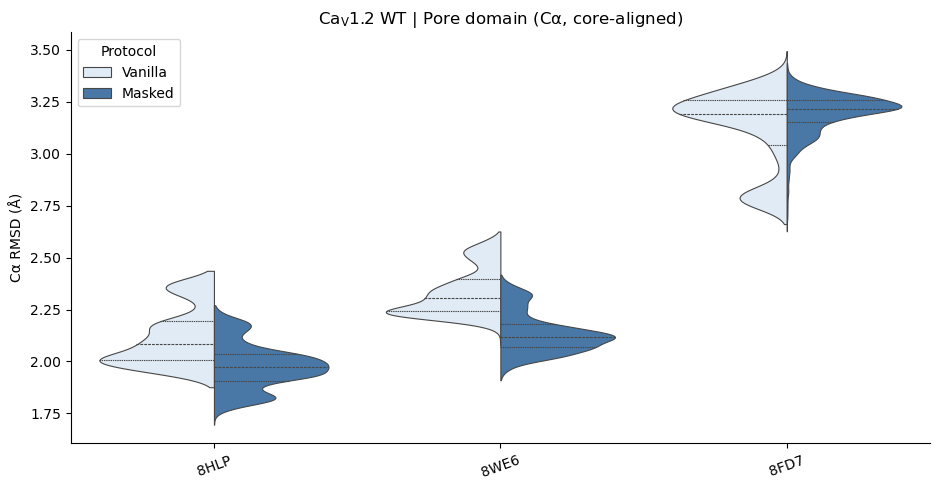

In [5]:
overall=next((c for c in measurements if any(x in c.lower() for x in ['whole','best_mapping_core','stable_core'])),measurements[0])
fig,ax=plt.subplots(figsize=(9.5,5)); sns.violinplot(data=main_df,x='Reference',y=overall,hue='Protocol',hue_order=active_protocols,palette=PLOT_SETTINGS['colors'],split=len(active_protocols)==2,cut=0,inner='quart',density_norm='width',common_norm=False,linewidth=.8,ax=ax); ax.set(xlabel='',ylabel=PLOT_SETTINGS['rmsd_axis'],title=f"{PLOT_SETTINGS['channel_label']} {PLOT_SETTINGS['condition_label']} | {humanize_measurement(overall)}"); ax.tick_params(axis='x',rotation=20); sns.despine(); fig.tight_layout();fig.savefig(FIG/'03_overall_core_distribution.png',dpi=300); plt.show()

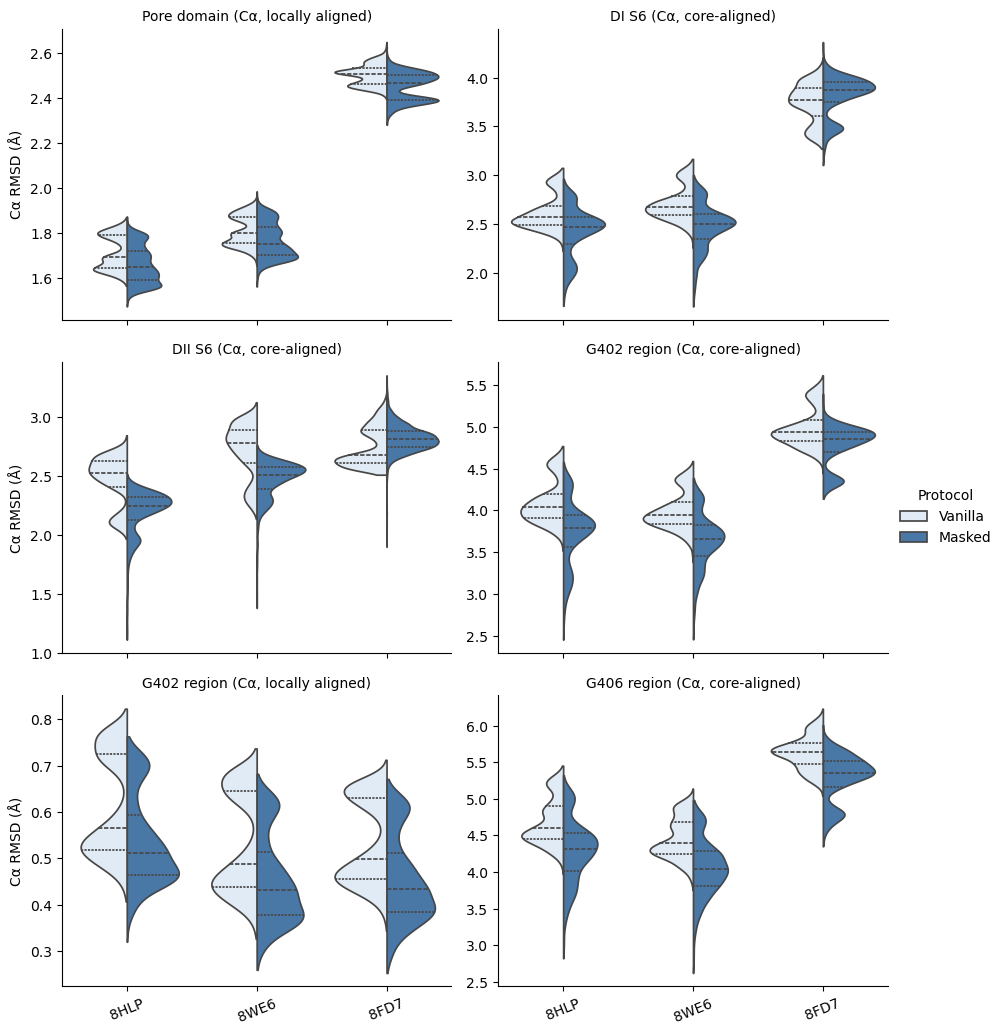

In [6]:
regional=[c for c in measurements if c!=overall][:6]
long=main_df.melt(id_vars=['Reference','Protocol'],value_vars=regional,var_name='measurement',value_name='RMSD')
long['Region']=long.measurement.map(humanize_measurement)
g=sns.catplot(data=long,x='Reference',y='RMSD',hue='Protocol',hue_order=active_protocols,col='Region',col_wrap=2,kind='violin',split=True,cut=0,inner='quart',sharey=False,palette=PLOT_SETTINGS['colors'],height=3.5,aspect=1.3)
g.set_titles('{col_name}'); g.set_axis_labels('',PLOT_SETTINGS['rmsd_axis']);
for ax in g.axes.flat: ax.tick_params(axis='x',rotation=22)
g.figure.savefig(FIG/'04_regional_distributions.png',dpi=300,bbox_inches='tight'); plt.show()

## Core-aligned versus locally aligned RMSD

A high core-aligned value with a low locally aligned value is consistent with a mostly rigid displacement relative to the channel core. High values in both indicate additional internal deformation.

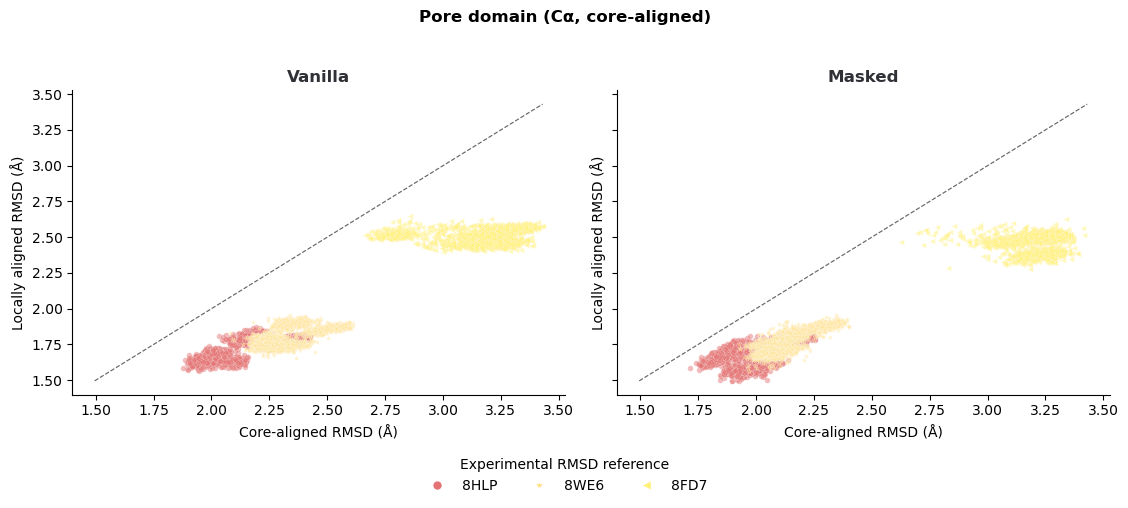

In [7]:
pairs=[]
for c in rmsd_columns(df):
    if '__core_aligned_rmsd_A' in c:
        local=c.replace('__core_aligned_rmsd_A','__local_aligned_rmsd_A')
        if local in df: pairs.append((c,local))
if pairs:
    core,local=pairs[0]; sample=main_df.sample(min(len(main_df),12000),random_state=403)
    if CHANNEL=='nav15':
        protocols=[x for x in ['Vanilla','Masked'] if x in set(sample.Protocol)]
        references=[x for x in ['7FBS','6UZ3','8VYJ','8VYK','7DTC','8T6L'] if x in set(sample.reference_id)]
        sample['local_minus_core_A']=pd.to_numeric(sample[local],errors='coerce')-pd.to_numeric(sample[core],errors='coerce')
        fig,ax=plt.subplots(figsize=(10.8,5.5))
        sns.violinplot(data=sample,x='reference_id',y='local_minus_core_A',hue='Protocol',order=references,hue_order=protocols,palette=PLOT_SETTINGS['colors'],split=len(protocols)==2,inner='quart',cut=0,linewidth=.75,density_norm='width',ax=ax)
        ax.axhline(0,color='#6F6875',lw=.9,ls=':')
        ymin,ymax=ax.get_ylim(); marker_y=ymax-(ymax-ymin)*.035
        for index,reference in enumerate(references):
            style=NAV15_EXPERIMENTAL_STYLES[reference]
            ax.scatter(index,marker_y,s=38,marker=style['marker'],facecolor='white',edgecolor=style['color'],linewidth=1.2,zorder=8)
        ax.set(xlabel='Experimental RMSD reference',ylabel='Local RMSD − core-aligned RMSD (Å)')
        ax.set_xticklabels([REFERENCE_LABELS[r] for r in references],rotation=20,ha='right')
        handles,labels=ax.get_legend_handles_labels(); ax.get_legend().remove()
        fig.suptitle(f"{PLOT_SETTINGS['channel_label']} {PLOT_SETTINGS['condition_label']} | pore-domain local relaxation",fontweight='semibold',y=.99)
        fig.legend(handles,labels,title='Protocol',loc='upper center',bbox_to_anchor=(.5,.94),ncol=2,frameon=False)
        sns.despine(ax=ax); fig.tight_layout(rect=(0,0,1,.88))
        fig.savefig(FIG/'05_core_vs_local.png',dpi=300,bbox_inches='tight')
        # Preserve the raw two-dimensional relationship as supplemental QC.
        fig_qc,axes=plt.subplots(1,len(protocols),figsize=(5.6*len(protocols),4.8),squeeze=False,sharex=True,sharey=True)
        for axis,protocol in zip(axes.flat,protocols):
            part=sample[sample.Protocol.eq(protocol)]
            for reference,refpart in part.groupby('reference_id',sort=False):
                style=NAV15_EXPERIMENTAL_STYLES[reference]
                axis.scatter(refpart[core],refpart[local],s=8,alpha=.18,marker=style['marker'],color=style['color'],linewidths=0)
            axis.set(title=protocol,xlabel='Core-aligned RMSD (Å)',ylabel='Locally aligned RMSD (Å)'); sns.despine(ax=axis)
        fig_qc.suptitle('Supplemental QC | raw core-versus-local RMSD',fontweight='semibold')
        fig_qc.tight_layout(); fig_qc.savefig(FIG/'S3_core_vs_local_scatter_QC.png',dpi=300,bbox_inches='tight')
    else:
        protocols=[x for x in ['Vanilla','Masked'] if x in set(sample.Protocol)]
        references=[r.split(' | ')[0] for r in PLOT_SETTINGS['reference_order'] if r.split(' | ')[0] in set(sample.reference_id)]
        fig,axes=plt.subplots(1,len(protocols),figsize=(5.7*len(protocols),5),squeeze=False,sharex=True,sharey=True)
        values=sample[[core,local]].apply(pd.to_numeric,errors='coerce').to_numpy(); lo=np.nanmin(values); hi=np.nanmax(values)
        for ax,protocol in zip(axes.flat,protocols):
            part=sample[sample.Protocol.eq(protocol)]
            for reference in references:
                refpart=part[part.reference_id.eq(reference)]; style=RMSD_REFERENCE_STYLES[reference]
                ax.scatter(refpart[core],refpart[local],s=16,alpha=.48,marker=style['marker'],facecolor=style['color'],edgecolor='white',linewidth=.22,rasterized=True)
            ax.plot([lo,hi],[lo,hi],ls='--',lw=.85,color='.4',zorder=0)
            ax.set(title=protocol,xlabel='Core-aligned RMSD (Å)',ylabel='Locally aligned RMSD (Å)'); ax.title.set_color('#2F3136'); ax.title.set_weight('bold'); sns.despine(ax=ax)
        handles=[Line2D([0],[0],linestyle='none',marker=RMSD_REFERENCE_STYLES[r]['marker'],markerfacecolor=RMSD_REFERENCE_STYLES[r]['color'],markeredgecolor='white',markersize=7,label=REFERENCE_LABELS[r]) for r in references]
        fig.suptitle(humanize_measurement(core),fontweight='semibold'); fig.legend(handles=handles,title='Experimental RMSD reference',loc='lower center',bbox_to_anchor=(.5,-.01),ncol=len(handles),frameon=False)
        fig.tight_layout(rect=(0,.09,1,.95)); fig.savefig(FIG/'05_core_vs_local.png',dpi=300,bbox_inches='tight')
    plt.show()
else: print('No matched core/local RMSD pair is available.')

## Effect of masking within each experimental reference

The **protocol median difference** is

$$\Delta_{\mathrm{protocol}}=\mathrm{median}(RMSD_{\mathrm{masked},R})-\mathrm{median}(RMSD_{\mathrm{vanilla},R}).$$

It compares protocols against the same reference $R$. Negative values mean that the masked ensemble is closer to that reference; positive values mean that vanilla is closer. This quantity does **not** say whether a model is more WT-like or mutant-like.

In [8]:
stats=summary_statistics(df,measurements); effects=protocol_effects(df,measurements)
main_effects=protocol_effects(main_df,measurements)
stats.to_csv(OUT/'summary_statistics.csv',index=False); effects.to_csv(OUT/'effect_sizes.csv',index=False)
display(main_effects.sort_values('masked_minus_vanilla_median',key=abs,ascending=False).head(15))

,sequence_condition,reference_id,comparison_protocol,measurement,n_vanilla,n_masked,vanilla_median,masked_median,masked_minus_vanilla_median,bootstrap_ci_low,bootstrap_ci_high,cliffs_delta_masked_vs_vanilla,recycle_dependence_note
8,wt,8FD7,Masked,IVS6__ca__core_aligned_rmsd_A,5000,4996,3.640216,3.238741,-0.401475,-0.411466,-0.391478,-0.941404,Recycle snapshots pooled; effect size is descr...
34,wt,8WE6,Masked,small_residue_nexus__ca__core_aligned_rmsd_A,5000,4996,3.878709,3.485046,-0.393663,-0.402851,-0.386802,-0.787812,Recycle snapshots pooled; effect size is descr...
22,wt,8HLP,Masked,small_residue_nexus__ca__core_aligned_rmsd_A,5000,4996,3.820367,3.429839,-0.390529,-0.403094,-0.380381,-0.792937,Recycle snapshots pooled; effect size is descr...
33,wt,8WE6,Masked,IS6_IVS6_interface__ca__core_aligned_rmsd_A,5000,4996,4.545368,4.185849,-0.359519,-0.368478,-0.349671,-0.603986,Recycle snapshots pooled; effect size is descr...
30,wt,8WE6,Masked,g406_region__ca__core_aligned_rmsd_A,5000,4996,4.396899,4.046031,-0.350868,-0.366675,-0.335693,-0.607738,Recycle snapshots pooled; effect size is descr...
21,wt,8HLP,Masked,IS6_IVS6_interface__ca__core_aligned_rmsd_A,5000,4996,4.688599,4.338290,-0.350309,-0.366618,-0.335666,-0.610258,Recycle snapshots pooled; effect size is descr...
9,wt,8FD7,Masked,IS6_IVS6_interface__ca__core_aligned_rmsd_A,5000,4996,5.429103,5.103403,-0.325700,-0.336196,-0.316954,-0.660002,Recycle snapshots pooled; effect size is descr...
10,wt,8FD7,Masked,small_residue_nexus__ca__core_aligned_rmsd_A,5000,4996,4.372012,4.063117,-0.308895,-0.313617,-0.303904,-0.830596,Recycle snapshots pooled; effect size is descr...
18,wt,8HLP,Masked,g406_region__ca__core_aligned_rmsd_A,5000,4996,4.604701,4.315101,-0.289600,-0.303861,-0.273212,-0.542872,Recycle snapshots pooled; effect size is descr...
28,wt,8WE6,Masked,g402_region__ca__core_aligned_rmsd_A,5000,4996,3.946855,3.657328,-0.289528,-0.299591,-0.277141,-0.650364,Recycle snapshots pooled; effect size is descr...


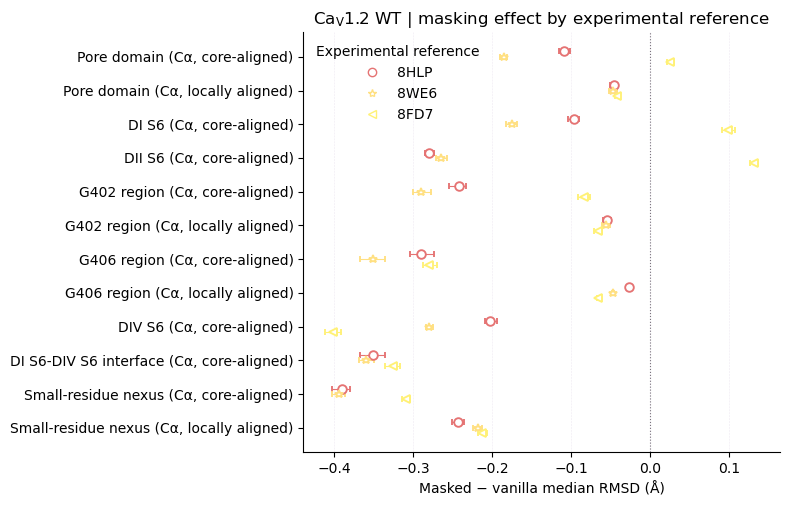

In [9]:
plot=main_effects.dropna(subset=['masked_minus_vanilla_median']).copy();plot['label']=plot.measurement.map(humanize_measurement);plot['comparison']=plot.reference_id.astype(str)+' | '+plot.comparison_protocol.astype(str)
if CHANNEL=='nav15':
    focus=[
      ('pore_domain__ca__core_aligned_rmsd_A','Pore domain'),
      ('DII_s6__ca__core_aligned_rmsd_A','DII S6'),
      ('ifm_motif__ca__core_aligned_rmsd_A','IFM/QQQ motif'),
      ('ifm_receptor_pocket__ca__core_aligned_rmsd_A','IFM receptor pocket'),
    ]
    focus=[item for item in focus if item[0] in set(plot.measurement)]
    references=[x for x in ['7FBS','6UZ3','8VYJ','8VYK','7DTC','8T6L'] if x in set(plot.reference_id)]
    fig,ax=plt.subplots(figsize=(9.4,4.8)); offsets=np.linspace(-.24,.24,len(references))
    for region_index,(measurement,region_label) in enumerate(focus):
        for offset,reference in zip(offsets,references):
            row=plot[(plot.measurement==measurement)&(plot.reference_id==reference)]
            if row.empty: continue
            row=row.iloc[0]; value=row.masked_minus_vanilla_median
            low=row.bootstrap_ci_low; high=row.bootstrap_ci_high
            style=NAV15_EXPERIMENTAL_STYLES[reference]
            ax.errorbar(value,region_index+offset,xerr=[[value-low],[high-value]],fmt=style['marker'],ms=6,mfc='white',mec=style['color'],mew=1.25,ecolor=style['color'],elinewidth=.8,capsize=2,zorder=4)
    ax.axvline(0,color='#6F6875',lw=1,ls=':'); ax.set_yticks(range(len(focus)),[x[1] for x in focus])
    ax.invert_yaxis(); ax.set(xlabel='Masked − vanilla median RMSD (Å)',ylabel='',title=f"{PLOT_SETTINGS['channel_label']} {PLOT_SETTINGS['condition_label']} | regional effect of the original mask")
    ax.text(.01,-.17,'← closer to the experimental reference',transform=ax.transAxes,ha='left',fontsize=8.5,color='#5F5666')
    ax.text(.99,-.17,'farther from the experimental reference →',transform=ax.transAxes,ha='right',fontsize=8.5,color='#5F5666')
    handles=[Line2D([0],[0],linestyle='none',marker=NAV15_EXPERIMENTAL_STYLES[r]['marker'],markerfacecolor='white',markeredgecolor=NAV15_EXPERIMENTAL_STYLES[r]['color'],markersize=6,label=REFERENCE_LABELS[r]) for r in references]
    ax.legend(handles=handles,title='Experimental reference',bbox_to_anchor=(.5,-.28),loc='upper center',ncol=3,frameon=False); ax.grid(axis='x',color='#EEE9F2',lw=.45,ls='--');sns.despine(ax=ax); fig.tight_layout(rect=(0,.18,1,1))
    fig.savefig(FIG/'06_median_differences.png',dpi=300,bbox_inches='tight')
    # Retain the complete regional effect forest as supplemental QC.
    full_measurements=list(dict.fromkeys(plot.measurement)); full_labels=[humanize_measurement(x) for x in full_measurements]
    fig_full,ax_full=plt.subplots(figsize=(8,max(5,.58*len(full_measurements)))); full_offsets=np.linspace(-.24,.24,len(references))
    for region_index,measurement in enumerate(full_measurements):
        for offset,reference in zip(full_offsets,references):
            row=plot[(plot.measurement==measurement)&(plot.reference_id==reference)]
            if row.empty: continue
            style=NAV15_EXPERIMENTAL_STYLES[reference]
            ax_full.scatter(row.masked_minus_vanilla_median.iloc[0],region_index+offset,s=34,marker=style['marker'],facecolor='white',edgecolor=style['color'],linewidth=1.1,zorder=4)
    ax_full.axvline(0,color='#6F6875',lw=.9,ls=':'); ax_full.set_yticks(range(len(full_measurements)),full_labels);ax_full.invert_yaxis()
    ax_full.set(xlabel='Masked − vanilla median RMSD (Å)',ylabel='',title='Supplemental | all regional masking effects'); ax_full.grid(axis='x',color='#EEE9F2',lw=.45,ls='--')
    ax_full.legend(handles=handles,title='Experimental reference',bbox_to_anchor=(.5,-.08),loc='upper center',ncol=3,frameon=False);sns.despine(ax=ax_full); fig_full.tight_layout(rect=(0,.08,1,1)); fig_full.savefig(FIG/'S4_all_regional_median_differences.png',dpi=300,bbox_inches='tight')
else:
    labels=list(dict.fromkeys(plot.label)); references=[r for r in PLOT_SETTINGS['reference_order'] if r.split(' | ')[0] in set(plot.reference_id)]
    reference_ids=[r.split(' | ')[0] for r in references]; offsets=np.linspace(-.16,.16,len(reference_ids))
    fig,ax=plt.subplots(figsize=(8,max(4,.43*len(labels))));
    for label_index,label in enumerate(labels):
        for offset,reference in zip(offsets,reference_ids):
            row=plot[(plot.label==label)&(plot.reference_id==reference)]
            if row.empty: continue
            row=row.iloc[0]; value=row.masked_minus_vanilla_median
            style=RMSD_REFERENCE_STYLES[reference]
            ax.errorbar(value,label_index+offset,xerr=[[value-row.bootstrap_ci_low],[row.bootstrap_ci_high-value]],fmt=style['marker'],ms=6.2,mfc='white',mec=style['color'],mew=1.35,ecolor=style['color'],elinewidth=.8,capsize=2,zorder=4)
    ax.axvline(0,color='#7A737D',lw=.8,ls=':');ax.set_yticks(range(len(labels)),labels);ax.invert_yaxis()
    ax.set(xlabel='Masked − vanilla median RMSD (Å)',ylabel='',title=f"{PLOT_SETTINGS['channel_label']} {PLOT_SETTINGS['condition_label']} | masking effect by experimental reference")
    handles=[Line2D([0],[0],linestyle='none',marker=RMSD_REFERENCE_STYLES[r]['marker'],markerfacecolor='white',markeredgecolor=RMSD_REFERENCE_STYLES[r]['color'],markersize=6,label=REFERENCE_LABELS[r]) for r in reference_ids]
    ax.legend(handles=handles,title='Experimental reference',loc='best',frameon=False);ax.grid(axis='x',color='#EEE9F2',lw=.4,ls='--');sns.despine();fig.tight_layout();    fig.savefig(FIG/'06_median_differences.png',dpi=300)
plt.show()

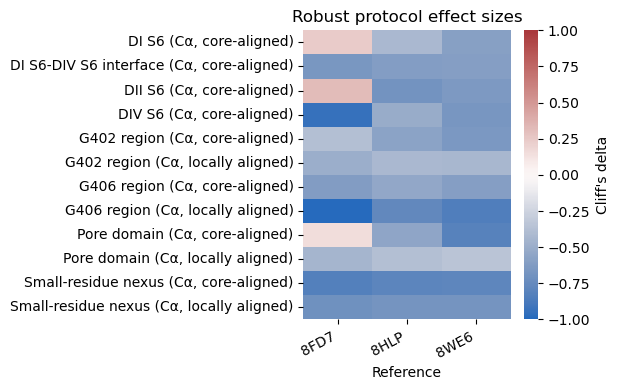

In [10]:
heat_source=main_effects.assign(column=main_effects.reference_id.map(REFERENCE_LABELS).fillna(main_effects.reference_id),Region=main_effects.measurement.map(humanize_measurement))
heat=heat_source.pivot_table(index='Region',columns='column',values='cliffs_delta_masked_vs_vanilla')
fig,ax=plt.subplots(figsize=(6,max(4,.32*len(heat)))); sns.heatmap(heat,cmap='vlag',center=0,vmin=-1,vmax=1,ax=ax,cbar_kws={'label':"Cliff's delta"}); ax.set(xlabel='Reference',ylabel='',title='Robust protocol effect sizes'); ax.tick_params(axis='x',rotation=28);plt.setp(ax.get_xticklabels(),ha='right'); fig.tight_layout();fig.savefig(FIG/'07_effect_size_heatmap.png',dpi=300); plt.show()

## Which experimental structure does each model resemble?

This is a paired, per-model comparison. For references A and B,

$$\Delta_{B-A}=RMSD_B-RMSD_A.$$

A negative value means the model is closer to reference B; a positive value means it is closer to reference A. The scatterplot shows the two RMSDs directly, with the identity line marking equal resemblance. Histograms show the signed preference score, and the table reports the fraction of paired models closer to either reference. These comparisons measure structural resemblance, not functional state by themselves.

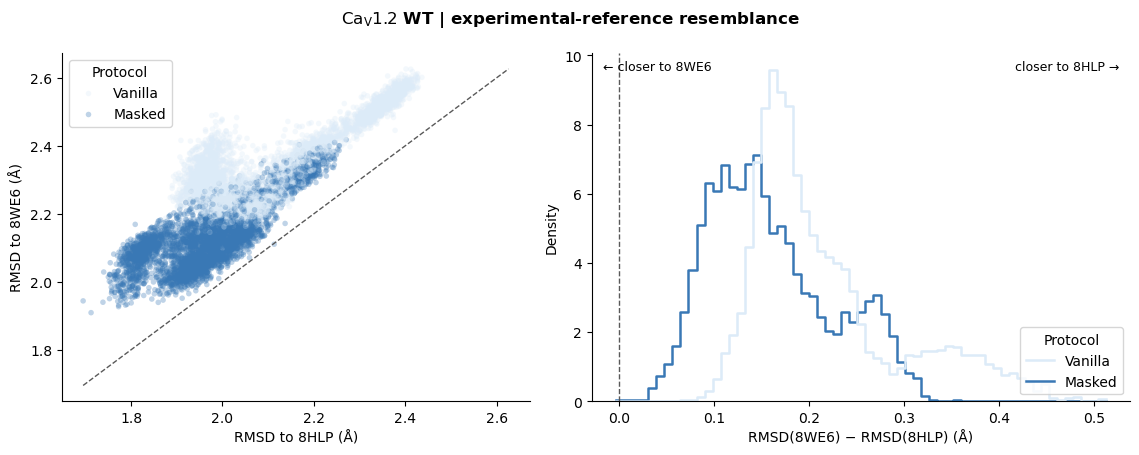

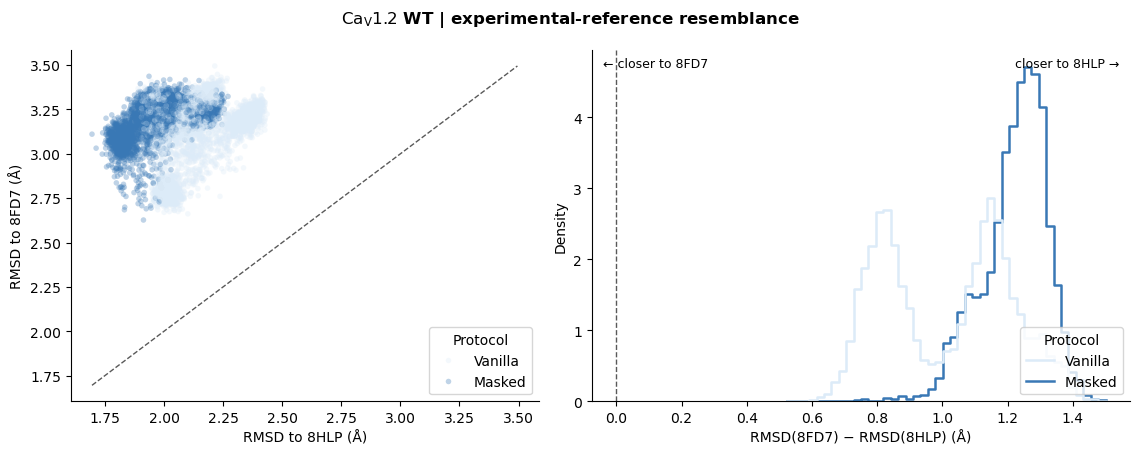

,protocol,reference_a,reference_b,measurement,n_paired_models,median_delta_b_minus_a_A,fraction_closer_to_a,fraction_closer_to_b,fraction_tied
0,Masked,8HLP,8WE6,pore_domain__ca__core_aligned_rmsd_A,4996,0.147020,0.9998,0.0002,0.0
1,Vanilla,8HLP,8WE6,pore_domain__ca__core_aligned_rmsd_A,5000,0.189583,1.0000,0.0000,0.0
2,Masked,8HLP,8FD7,pore_domain__ca__core_aligned_rmsd_A,4996,1.237764,1.0000,0.0000,0.0
3,Vanilla,8HLP,8FD7,pore_domain__ca__core_aligned_rmsd_A,5000,1.048684,1.0000,0.0000,0.0


In [11]:
REFERENCE_PAIRS={
 'kv21':[('8SD3','8SDA')],
 'nav15':[('8VYJ','7FBS'),('8VYK','7FBS'),('8VYJ','7DTC')],
 'cav12':[('8HLP','8WE6'),('8HLP','8FD7')],
}[CHANNEL]
preference_tables=[]; preference_summaries=[]
for ref_a,ref_b in REFERENCE_PAIRS:
    paired=reference_preference(main_df,overall,ref_a,ref_b)
    if paired.empty:
        print(f'No complete paired observations for {ref_a} versus {ref_b}.'); continue
    summary=summarize_reference_preference(paired)
    preference_tables.append(paired); preference_summaries.append(summary)
    safe=f'{ref_a}_vs_{ref_b}'
    paired.to_csv(OUT/f'reference_preference_{safe}.csv',index=False)
    summary.to_csv(OUT/f'reference_preference_summary_{safe}.csv',index=False)
    fig,(ax_scatter,ax_hist)=plt.subplots(1,2,figsize=(11.5,4.6),gridspec_kw={'width_ratios':[1,1.15]})
    sample=paired.sample(min(len(paired),12000),random_state=412)
    sns.scatterplot(data=sample,x='rmsd_reference_a_A',y='rmsd_reference_b_A',hue='Protocol',hue_order=active_protocols,palette=PLOT_SETTINGS['colors'],s=16,alpha=.32,linewidth=0,ax=ax_scatter)
    lo=np.nanmin(sample[['rmsd_reference_a_A','rmsd_reference_b_A']].to_numpy()); hi=np.nanmax(sample[['rmsd_reference_a_A','rmsd_reference_b_A']].to_numpy())
    ax_scatter.plot([lo,hi],[lo,hi],ls='--',lw=1,color='.35'); ax_scatter.set(xlabel=f'RMSD to {REFERENCE_LABELS.get(ref_a,ref_a)} (Å)',ylabel=f'RMSD to {REFERENCE_LABELS.get(ref_b,ref_b)} (Å)')
    sns.histplot(data=paired,x='delta_b_minus_a_A',hue='Protocol',hue_order=active_protocols,palette=PLOT_SETTINGS['colors'],element='step',fill=False,stat='density',common_norm=False,linewidth=1.8,ax=ax_hist)
    ax_hist.axvline(0,ls='--',lw=1,color='.35'); ax_hist.set(xlabel=f"RMSD({REFERENCE_LABELS.get(ref_b,ref_b)}) − RMSD({REFERENCE_LABELS.get(ref_a,ref_a)}) (Å)",ylabel='Density')
    sns.move_legend(ax_hist,'lower right',title='Protocol',frameon=True)
    ax_hist.text(.02,.98,f"← closer to {REFERENCE_LABELS.get(ref_b,ref_b)}",transform=ax_hist.transAxes,ha='left',va='top',fontsize=9)
    ax_hist.text(.98,.98,f"closer to {REFERENCE_LABELS.get(ref_a,ref_a)} →",transform=ax_hist.transAxes,ha='right',va='top',fontsize=9)
    resemblance_label='WT (8SD3) versus L403A mutant (8SDA)' if CHANNEL=='kv21' else 'experimental-reference'
    fig.suptitle(f"{PLOT_SETTINGS['channel_label']} {PLOT_SETTINGS['condition_label']} | {resemblance_label} resemblance",fontweight='bold')
    sns.despine(); fig.tight_layout(); fig.savefig(FIG/f'reference_preference_{safe}.png',dpi=300,bbox_inches='tight'); plt.show()
if preference_summaries:
    preference_summary=pd.concat(preference_summaries,ignore_index=True)
    display(preference_summary)
else: preference_summary=pd.DataFrame()

## Experimental-baseline entry

No separate reference-to-reference baseline is assumed. If a compatible baseline column is present in the table, the next cell reports entry fractions; otherwise it records that this analysis is unavailable.

,status
0,Separate experimental reference-to-reference b...


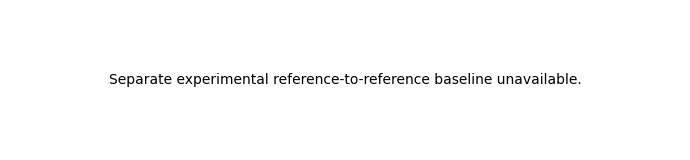

In [12]:
baseline_cols=[c for c in df if 'baseline' in c.lower() and ('rmsd' in c.lower() or 'range' in c.lower())]
if baseline_cols:
    baseline_note=pd.DataFrame({'available_column':baseline_cols})
else:
    baseline_note=pd.DataFrame({'status':['Separate experimental reference-to-reference baseline unavailable.']})
baseline_note.to_csv(OUT/'experimental_baseline_status.csv',index=False); display(baseline_note)
fig,ax=plt.subplots(figsize=(7,1.7)); ax.axis('off'); ax.text(.5,.5,baseline_note.iloc[0,0],ha='center',va='center',wrap=True); fig.tight_layout();fig.savefig(FIG/'08_experimental_baseline_status.png',dpi=300); plt.show()

## Interpretation and limitations

The effect-size table should be read together with measurement coverage and chain-mapping quality control. A lower masked median means that the masked ensemble is closer to the specified experimental geometry for that coordinate; it does not by itself establish a functional state. Agreement across complementary regions is stronger evidence than an isolated RMSD shift, particularly when core-aligned and locally aligned measurements differ.